In [1]:
### Importing the required library 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
from rdkit.Chem import MolStandardize
import joblib

import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors,rdMolDescriptors
#import openpyxl


In [2]:
### Installation of the basic library 
from rdkit import Chem,DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import Crippen
import numpy as np

In [3]:
### Reading the preprocess data from disk 
### Train data 
train_set=pd.read_csv('data/final_unique_train.csv')

### test data 
test_set=pd.read_csv('data/unique_test_new24.csv')

print(train_set.shape)
print(test_set.shape)

(17937, 8)
(1282, 4)


In [4]:
### Making smiles to list 
train_smiles_list=train_set[['smiles_canon']]
test_smiles_list=test_set[['smiles_canon']]

In [6]:

### Importing the function of the utility file to generate the descriptors and others evaluation matrics...  
import utilities

In [7]:
### Generate 4 descriptors ....
df4_train=utilities.generate4(train_set.smiles_canon)
df4_test=utilities.generate4(test_set.smiles_canon)
### Generate 17 descriptors ....
df17_train=utilities.generate17(train_set.smiles_canon)
df17_test=utilities.generate17(test_set.smiles_canon)
### Generate 123 descriptors ....
df123_train=utilities.generate123(train_set.smiles_canon)
df123_test=utilities.generate123(test_set.smiles_canon)
### Generate 38 feature engineered based on the structure of the smiles ....
df38_train=utilities.generate_features38(train_set.smiles_canon)
df38_test=utilities.generate_features38(test_set.smiles_canon)
### Generate 7 funnctional groups
df7_train=utilities.get_functional_groups(train_set.smiles_canon)
df7_test=utilities.get_functional_groups(test_set.smiles_canon)
### Fingerprint 128....
df128_train=utilities.fingerprint(train_set.smiles_canon,2,128)
df128_test=utilities.fingerprint(test_set.smiles_canon,2,128)
### Fingerprint 256....
df256_train=utilities.fingerprint(train_set.smiles_canon,2,256)
df256_test=utilities.fingerprint(test_set.smiles_canon,2,256)
### Fingerprint 512....
df512_train=utilities.fingerprint(train_set.smiles_canon,2,512)
df512_test=utilities.fingerprint(test_set.smiles_canon,2,512)
### Fingerprint 1024....
df1024_train=utilities.fingerprint(train_set.smiles_canon,2,1024)
df1024_test=utilities.fingerprint(test_set.smiles_canon,2,1024)

In [9]:
y_train=train_set.copy()['LogS']
y_test=test_set.copy()['Solubility']

In [14]:
### Importing library to evaluate the best model 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgboost
from xgboost import XGBRegressor


In [33]:
import xgboost #as xgb
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

In [10]:
### 125 and 128 fingerprint  
df253_train=pd.concat([df123_train, df128_train], axis=1)
df253_test=pd.concat([df123_test, df128_test], axis=1)

In [11]:
### 125 standard features , 128 fingerprint  7 functional group 
df260_train=pd.concat([df253_train, df7_train], axis=1)
df260_test=pd.concat([df253_test, df7_test], axis=1)

In [12]:
### 125 + 128 fp and 7 functional group + 38 featured engineered 
df298_train=pd.concat([df260_train, df38_train], axis=1)
df298_test=pd.concat([df260_test, df38_test], axis=1)

In [230]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(df298_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df298_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_298=utilities.get_errors1(y_test,pred_xgb,"XGB_298")

In [16]:
xgb_298['Descriptors_Detail']='125 features + 128 fingerprint 7 f_group+38 fe features'

In [231]:
xgb_298

,Model_Name,MAE,MSE,RMSE,R2
0,XGB_298,0.4045,0.3036,0.551,0.9272


In [232]:
df298_train

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,zero_bonds,conjugated_bonds,bonds_in_ring,chirality_none,chirality_any,chirality_z,chirality_e,n_atoms,n_bonds,n_rings
0,12.237685,12.237685,0.141019,-0.179815,0.607025,13.235294,242.661,235.605,242.013457,82.0,...,0,18,3,26,0,0,0,24,26,3
1,11.365576,11.365576,0.000093,-3.793889,0.338496,10.857143,214.250,204.170,214.052447,76.0,...,0,10,1,24,0,0,0,24,24,1
2,14.710818,14.710818,0.013989,-1.286529,0.885824,22.920000,345.374,325.214,345.148870,132.0,...,0,16,4,48,0,0,0,45,48,4
3,11.728912,11.728912,0.079902,-0.609578,0.458568,16.470588,235.239,222.135,235.084458,90.0,...,0,12,2,31,0,0,0,30,31,2
4,11.210467,11.210467,0.109352,-0.262778,0.476619,17.538462,173.171,166.115,173.047678,64.0,...,0,14,2,21,0,0,0,20,21,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17932,4.333333,4.333333,1.513889,1.513889,0.447261,8.000000,69.063,66.039,69.021464,26.0,...,0,5,1,8,0,0,0,8,8,1
17933,5.255345,5.255345,0.765000,0.765000,0.631387,10.857143,184.198,176.134,184.063663,68.0,...,0,16,3,24,0,0,0,22,24,3
17934,3.555556,3.555556,1.444444,1.444444,0.458207,8.000000,69.067,66.043,69.032697,26.0,...,0,5,1,8,0,0,0,8,8,1
17935,3.912037,3.912037,0.712963,0.712963,0.545467,10.222222,120.115,116.083,120.043596,44.0,...,0,10,2,14,0,0,0,13,14,2


In [233]:
### Converting integer column to string 
df298_train.columns = df298_train.columns.astype(str)

In [244]:
x=feature_importance_df['Feature'][:20]

In [245]:
x

123                    MolLogP
124                      MolMR
42                         Ipc
112     NumAromaticCarbocycles
32                        Chi1
57                   PEOE_VSA6
275            atoms_valence_6
274            atoms_valence_5
96                VSA_EState10
273            atoms_valence_4
108                    NOCount
75                  SlogP_VSA2
47                   PEOE_VSA1
253             Hydroxyl Group
289           conjugated_bonds
28                     BertzCT
7               HeavyAtomMolWt
119    NumSaturatedCarbocycles
164                         39
8                   ExactMolWt
Name: Feature, dtype: object

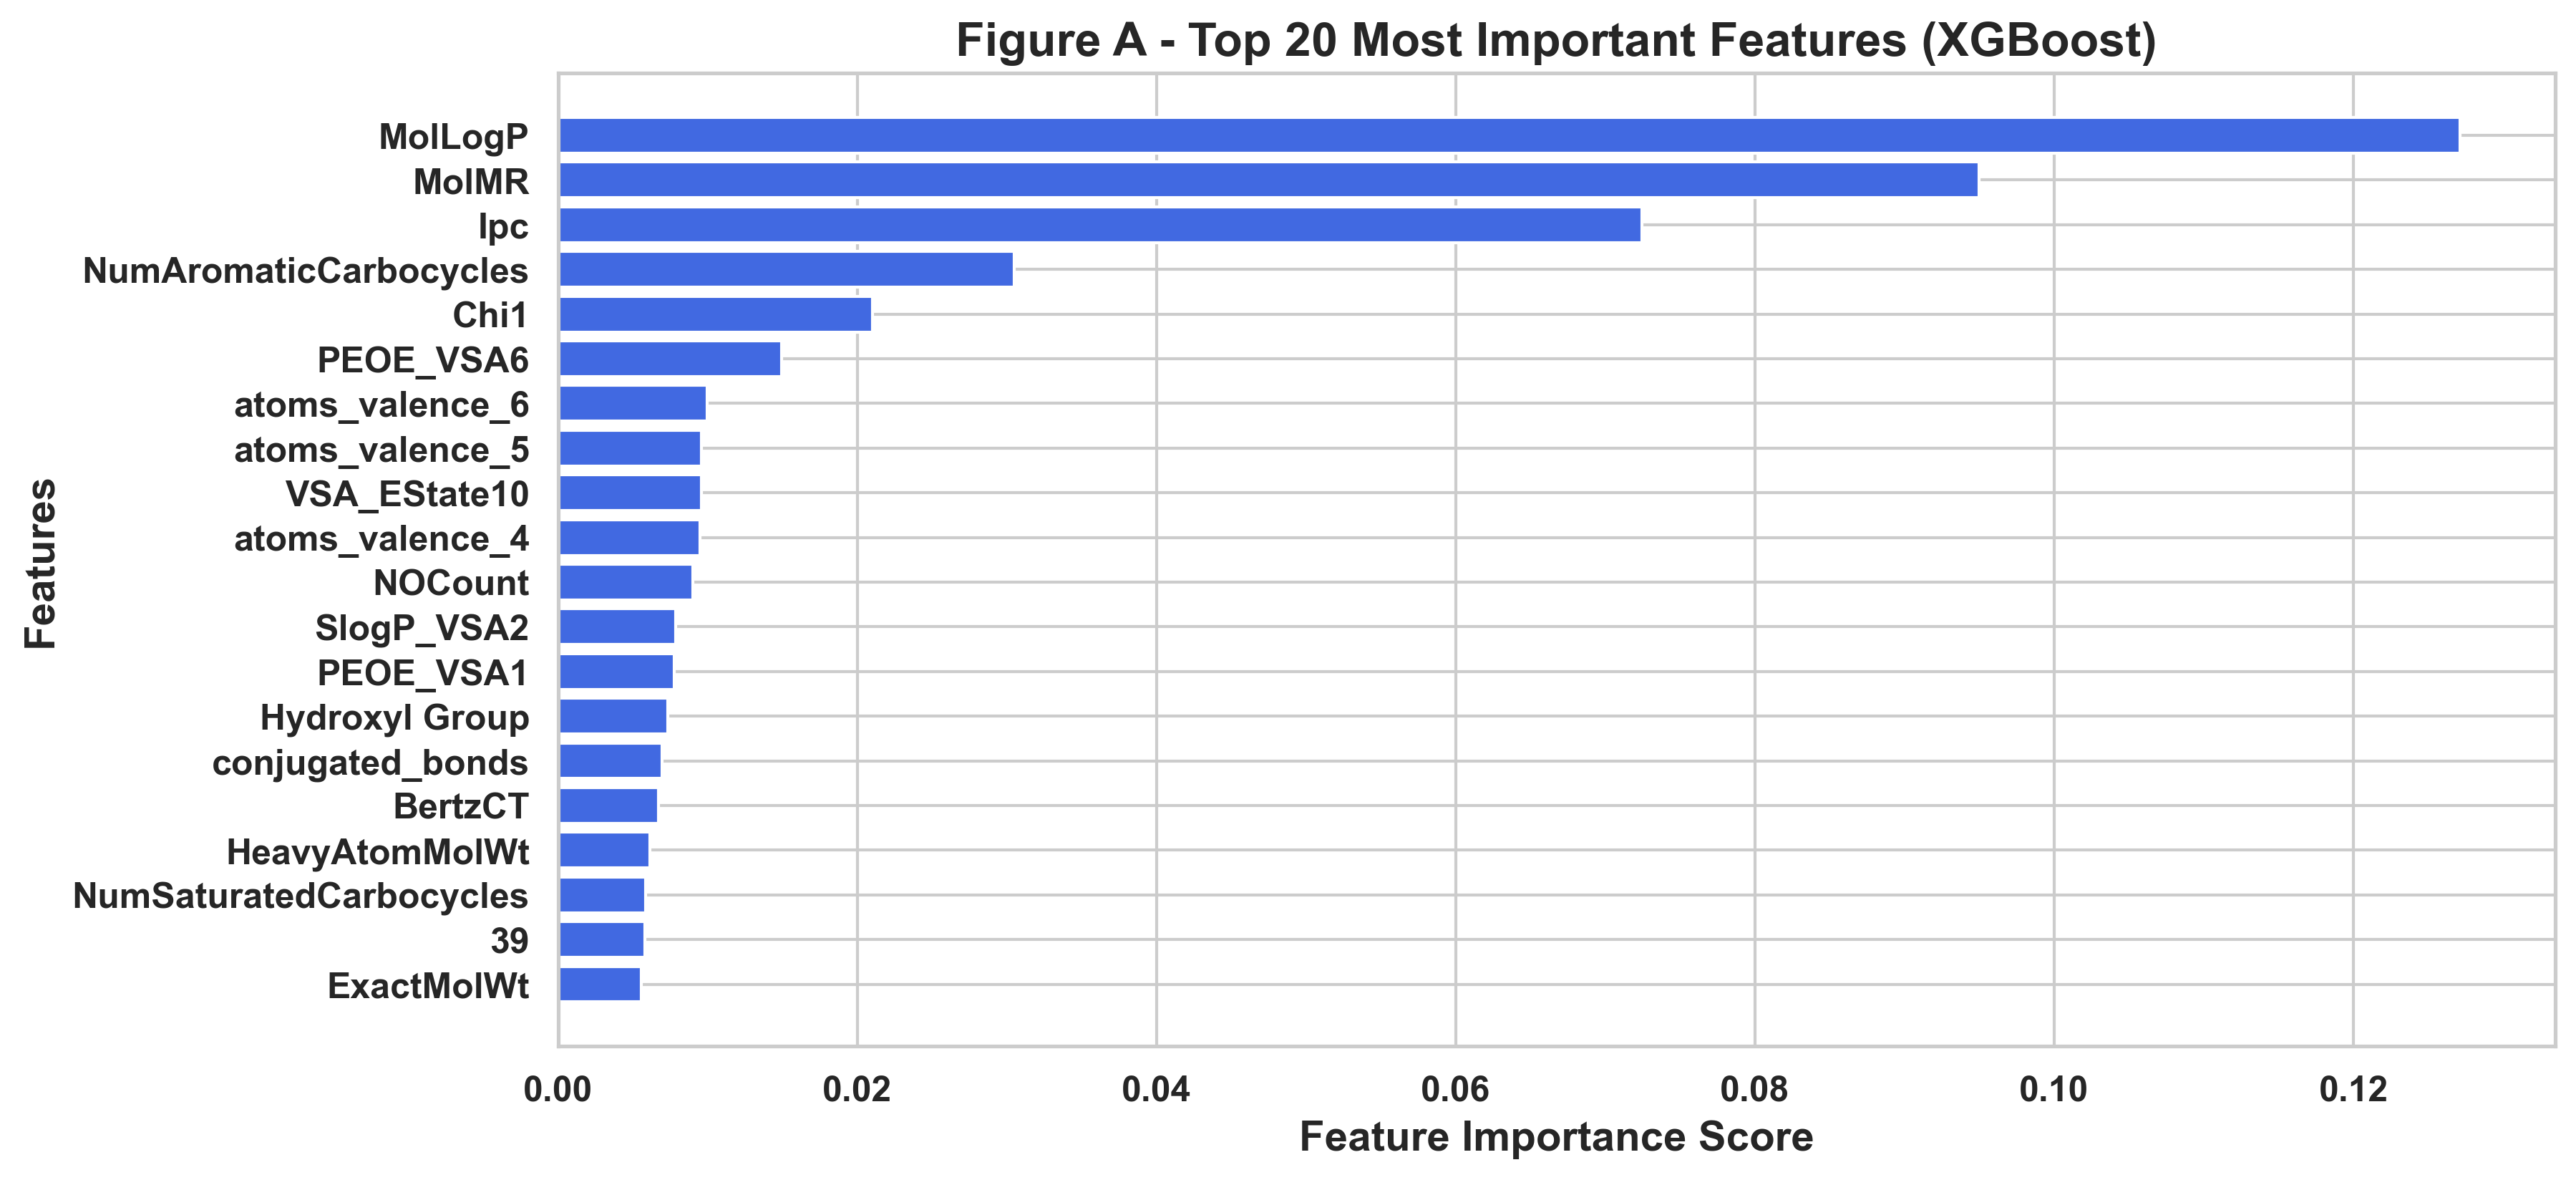

In [236]:

### Extracting top 20 important features 
import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importance from the trained XGBoost model
feature_importance = xgboost_model.feature_importances_

# Convert to DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': df298_train.columns,
    'Importance': feature_importance
})

# Sort by importance (highest to lowest)
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Plot the top 20 most important features
plt.figure(figsize=(12, 6), dpi=300)  # High resolution
plt.barh(feature_importance_df['Feature'][:20], feature_importance_df['Importance'][:20], color='royalblue')

# Labels and Title (Bold)
plt.xlabel("Feature Importance Score", fontsize=14, fontweight='bold')
plt.ylabel("Features", fontsize=14, fontweight='bold')
plt.title("Figure A - Top 20 Most Important Features (XGBoost)", fontsize=16, fontweight='bold')

# Make both x-axis and y-axis labels bold
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# Invert y-axis for better readability
plt.gca().invert_yaxis()

# Save the figure with high resolution
plt.savefig("xgboost_top20_features.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [118]:
N = 20  # Selecting Top 20 features 
top_features = feature_importance_df['Feature'][:N]  # Select top N descriptors
df298_train.columns = df298_train.columns.astype(str)
df298_test.columns = df298_test.columns.astype(str)
X_train_top = df298_train[top_features]
X_test_top = df298_test[top_features]


In [119]:
# Train model with top 20 features

xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(X_train_top,y_train)   
y_pred_top = xgboost_model.predict(X_test_top)
xgb_20=utilities.get_errors1(y_test,y_pred_top,"XGB_20")


In [120]:
xgb_20

,Model_Name,MAE,MSE,RMSE,R2
0,XGB_20,0.4586,0.3748,0.6122,0.9101


In [218]:
N = 50  # Selecting  50 features 
top_features = feature_importance_df['Feature'][:N]  # Select top N descriptors
df298_train.columns = df298_train.columns.astype(str)
df298_test.columns = df298_test.columns.astype(str)
X_train_top = df298_train[top_features]
X_test_top = df298_test[top_features]

In [122]:
# Train model with top 50 features

xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(X_train_top,y_train)   
y_pred_top = xgboost_model.predict(X_test_top)
xgb_50=utilities.get_errors1(y_test,y_pred_top,"XGB_50")

In [95]:
xgb_50

,Model_Name,MAE,MSE,RMSE,R2
0,XGB_298_50,0.4325,0.338,0.5814,0.919


In [123]:
N = 100  # Selecting  100 features 
top_features = feature_importance_df['Feature'][:N]  # Select top N descriptors
df298_train.columns = df298_train.columns.astype(str)
df298_test.columns = df298_test.columns.astype(str)
X_train_top = df298_train[top_features]
X_test_top = df298_test[top_features]

In [124]:
# Train model with top 100 features

xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(X_train_top,y_train)   
y_pred_top = xgboost_model.predict(X_test_top)
xgb_100=utilities.get_errors1(y_test,y_pred_top,"XGB_100")

In [125]:
xgb_100

,Model_Name,MAE,MSE,RMSE,R2
0,XGB_100,0.4124,0.3167,0.5628,0.9241


In [126]:
N = 150  # Selecting  150 features 
top_features = feature_importance_df['Feature'][:N]  # Select top N descriptors
df298_train.columns = df298_train.columns.astype(str)
df298_test.columns = df298_test.columns.astype(str)
X_train_top = df298_train[top_features]
X_test_top = df298_test[top_features]

In [127]:
# Train model with top 150 features

xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(X_train_top,y_train)   
y_pred_top = xgboost_model.predict(X_test_top)
xgb_150=utilities.get_errors1(y_test,y_pred_top,"XGB_150")

In [106]:
xgb_150

,Model_Name,MAE,MSE,RMSE,R2
0,XGB_298_150,0.4088,0.3127,0.5592,0.925


In [166]:
N = 200  # Selecting  200 features 
top_features = feature_importance_df['Feature'][:N]  # Select top N descriptors
df298_train.columns = df298_train.columns.astype(str)
df298_test.columns = df298_test.columns.astype(str)
X_train_top = df298_train[top_features]
X_test_top = df298_test[top_features]

In [167]:
# Train model with top 200 features

xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(X_train_top,y_train)   
y_pred_top = xgboost_model.predict(X_test_top)
xgb_200=utilities.get_errors1(y_test,y_pred_top,"XGB_200")

In [168]:
xgb_200

,Model_Name,MAE,MSE,RMSE,R2
0,XGB_200,0.4086,0.3104,0.5571,0.9256


In [130]:
N = 250  # Selecting  250 features 
top_features = feature_importance_df['Feature'][:N]  # Select top N descriptors
df298_train.columns = df298_train.columns.astype(str)
df298_test.columns = df298_test.columns.astype(str)
X_train_top = df298_train[top_features]
X_test_top = df298_test[top_features]

In [131]:
# Train model with top 250 features

xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(X_train_top,y_train)   
y_pred_top = xgboost_model.predict(X_test_top)
xgb_250=utilities.get_errors1(y_test,y_pred_top,"XGB_250")

In [132]:
xgb_250

,Model_Name,MAE,MSE,RMSE,R2
0,XGB_250,0.4057,0.3047,0.552,0.927


In [133]:
# Train model with all 298 features

xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(df298_train,y_train)   
y_pred_top = xgboost_model.predict(df298_test)
xgb_298=utilities.get_errors1(y_test,y_pred_top,"XGB_298")

In [134]:
xgb_298

,Model_Name,MAE,MSE,RMSE,R2
0,XGB_298,0.4045,0.3036,0.551,0.9272


In [169]:
df_combined = pd.concat([xgb_20,xgb_50,xgb_100,xgb_150,xgb_200,xgb_250,xgb_298], ignore_index=True)

In [238]:
df_combined=df_combined[['Model_Name','MAE','RMSE','R2']]

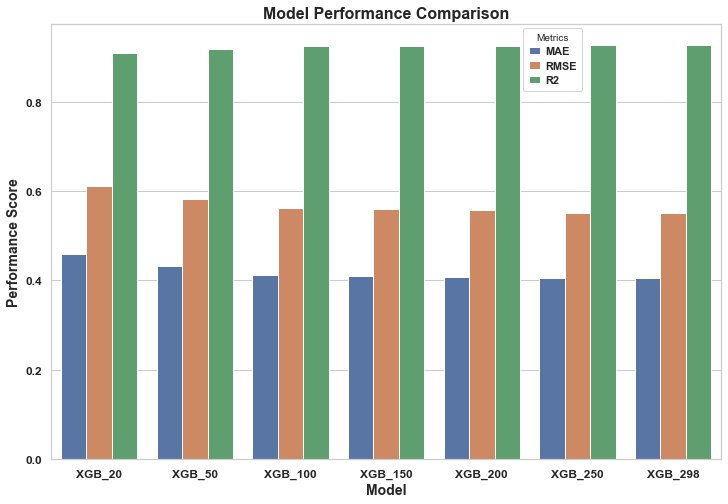

In [243]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Model' is string (categorical)
df_combined["Model_Name"] = df_combined["Model_Name"].astype(str)

# Melt the DataFrame
df_melted = df_combined.melt(id_vars=["Model_Name"], var_name="Metric", value_name="Value")

# Ensure 'Value' column is numeric
df_melted["Value"] = pd.to_numeric(df_melted["Value"], errors="coerce")

# Set style
sns.set_style("whitegrid")

# Increase figure size
plt.figure(figsize=(12, 8))  # Increased from (10,6) to (12,8) for better legend accommodation

# Plot
ax = sns.barplot(x="Model_Name", y="Value", hue="Metric", data=df_melted)

# Labels and title with bold font
plt.xlabel("Model", fontsize=14, fontweight='bold')  # Bold and larger font
plt.ylabel("Performance Score", fontsize=14, fontweight='bold')
plt.title("Model Performance Comparison", fontsize=16, fontweight='bold')

# Increase legend size and move it inside the plot
#plt.legend(title="Metrics", fontsize=12, title_fontsize=14, loc="best", frameon=True)
#plt.legend(title="Metrics", fontsize=10, title_fontsize=14, bbox_to_anchor=(0.84, 1), loc="upper left", frameon=True)
#plt.legend(title="Metrics", fontsize=8, title_fontsize=12, bbox_to_anchor=(0.84, 1), loc="upper left", frameon=True, prop={'weight': 'bold'})
plt.legend(
    title="Metrics",
    fontsize=8,                      # Smaller legend text
    title_fontsize=10,              # Smaller title
    bbox_to_anchor=(0.70, 1),
    loc="upper left",
    frameon=True,
    prop={'weight': 'bold'},
    labelspacing=0.4,               # Less space between labels
    handlelength=1,                 # Shorter line handles
    handletextpad=0.5,              # Less space between handle and text
    borderpad=0.5,                  # Padding inside the legend box
    borderaxespad=0.3               # Space between the axes and legend box
)

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=0, fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# Save figure with 300 dpi
plt.savefig("model_performance.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()
